# Análisis Exploratorio de Datos (EDA) - Dataset de Crédito Fintech

Este notebook contiene el análisis del conjunto de datos de 150 clientes de una fintech, enfocado en el análisis de riesgo crediticio. El objetivo es identificar qué variables influyen en la mora (`mora`).

### Estructura del Análisis:
1. **Preparación y Limpieza de Datos**
2. **Estadística Descriptiva**
3. **Análisis de Distribución (Polígono de Frecuencias)**
4. **Análisis de Valores Atípicos y Grupos (Diagrama de Caja)**
5. **Relación entre Variables (Diagrama de Dispersión)**
6. **Matriz de Correlación**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos para gráficos premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Cargar el dataset
file_path = 'data/raw/fintech_base_150_registros.xlsx'
df = pd.read_excel(file_path)
print(f"Dataset cargado con éxito. Dimensiones: {df.shape}")

Matplotlib is building the font cache; this may take a moment.


Dataset cargado con éxito. Dimensiones: (150, 13)


## 1. Limpieza y Validación de Datos

Aunque el dataset inicial parece estar estructurado, realizamos una limpieza y verificación formal:
- Búsqueda de valores nulos o faltantes.
- Detección y eliminación de registros duplicados.
- Estandarización de variables de texto (eliminar espacios en blanco adicionales, unificar mayúsculas/minúsculas).
- Mapear la variable objetivo `mora` a una categoría descriptiva para visualizaciones.
- Validación de consistencia lógica de las variables (por ejemplo, edades y montos mayores que cero).

In [2]:
# 1. Verificar valores nulos
print("--- Valores nulos por columna ---")
print(df.isnull().sum())

# 2. Verificar filas duplicadas
duplicados = df.duplicated().sum()
print(f"\nNúmero de registros duplicados: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print("Registros duplicados eliminados.")

# 3. Limpieza de columnas de texto (nivel_educativo, zona, historial_crediticio)
for col in ['nivel_educativo', 'zona', 'historial_crediticio']:
    df[col] = df[col].astype(str).str.strip().str.capitalize()

# 4. Mapear estado de mora para etiquetas legibles en gráficos
df['estado_cliente'] = df['mora'].map({0: 'Al día', 1: 'En Mora'})

# 5. Validaciones lógicas
# La edad debe ser positiva, el ingreso y monto del crédito también
invalid_edad = df[df['edad'] <= 0]
invalid_ingreso = df[df['ingreso_mensual'] < 0]
invalid_monto = df[df['monto_credito'] <= 0]

print(f"\nRegistros con edad inválida (<=0): {len(invalid_edad)}")
print(f"Registros con ingreso inválido (<0): {len(invalid_ingreso)}")
print(f"Registros con monto de crédito inválido (<=0): {len(invalid_monto)}")

# Mostrar resumen del dataset limpio
print("\n--- Información del Dataset Limpio ---")
df.info()

--- Valores nulos por columna ---
id_cliente              0
edad                    0
ingreso_mensual         0
monto_credito           0
cuotas                  0
tasa_interes            0
antiguedad_laboral      0
nivel_educativo         0
zona                    0
historial_crediticio    0
atrasos_previos         0
score_crediticio        0
mora                    0
dtype: int64

Número de registros duplicados: 0

Registros con edad inválida (<=0): 0
Registros con ingreso inválido (<0): 0
Registros con monto de crédito inválido (<=0): 0

--- Información del Dataset Limpio ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            150 non-null    int64  
 1   edad                  150 non-null    int64  
 2   ingreso_mensual       150 non-null    int64  
 3   monto_credito         150 non-null    int64  
 4   cuotas   

## 2. Estadística Descriptiva

Obtenemos un resumen estadístico de las variables numéricas y categóricas para entender las escalas, valores promedio, mínimos y máximos de la muestra.

In [3]:
# Resumen numérico
print("--- Resumen Estadístico de Variables Numéricas ---")
display(df.describe())

# Resumen de categóricas
print("\n--- Distribución de Variables Categóricas (en %) ---")
for col in ['nivel_educativo', 'zona', 'historial_crediticio', 'estado_cliente']:
    print(f"\nFrecuencia para {col.upper()}:")
    print(df[col].value_counts(normalize=True) * 100)

--- Resumen Estadístico de Variables Numéricas ---


,id_cliente,edad,ingreso_mensual,monto_credito,cuotas,tasa_interes,antiguedad_laboral,atrasos_previos,score_crediticio,mora
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,38.780000,447156.940000,290989.693333,7.393333,49.246000,10.200000,2.486667,583.753333,0.500000
std,43.445368,12.974353,204064.605553,136768.608453,2.837658,17.009103,5.838268,1.709573,160.892558,0.501675
min,1.000000,18.000000,109230.000000,50581.000000,3.000000,20.140000,0.200000,0.000000,302.000000,0.000000
25%,38.250000,28.250000,268406.250000,185755.000000,5.000000,33.465000,5.500000,1.000000,454.750000,0.000000
50%,75.500000,37.000000,446532.500000,298546.000000,7.500000,48.625000,10.850000,3.000000,580.500000,0.500000
75%,112.750000,49.500000,645121.500000,417013.500000,9.750000,63.385000,15.375000,4.000000,716.500000,1.000000
max,150.000000,65.000000,786913.000000,498558.000000,12.000000,79.780000,19.600000,5.000000,899.000000,1.000000



--- Distribución de Variables Categóricas (en %) ---

Frecuencia para NIVEL_EDUCATIVO:
nivel_educativo
Primario         29.333333
Universitario    27.333333
Secundario       23.333333
Terciario        20.000000
Name: proportion, dtype: float64

Frecuencia para ZONA:
zona
Periurbana    34.666667
Rural         33.333333
Urbana        32.000000
Name: proportion, dtype: float64

Frecuencia para HISTORIAL_CREDITICIO:
historial_crediticio
Malo       34.666667
Regular    33.333333
Bueno      32.000000
Name: proportion, dtype: float64

Frecuencia para ESTADO_CLIENTE:
estado_cliente
Al día     50.0
En Mora    50.0
Name: proportion, dtype: float64


## 3. Polígono de Frecuencias

Un **polígono de frecuencias** es una excelente herramienta para visualizar y comparar las formas de las distribuciones de variables continuas entre diferentes grupos.

A continuación, graficaremos:
1. **Edad:** Polígono de frecuencia manual construido calculando los centros de intervalos.
2. **Ingreso Mensual:** Polígono de frecuencia estilizado usando la funcionalidad `element='poly'` de Seaborn.

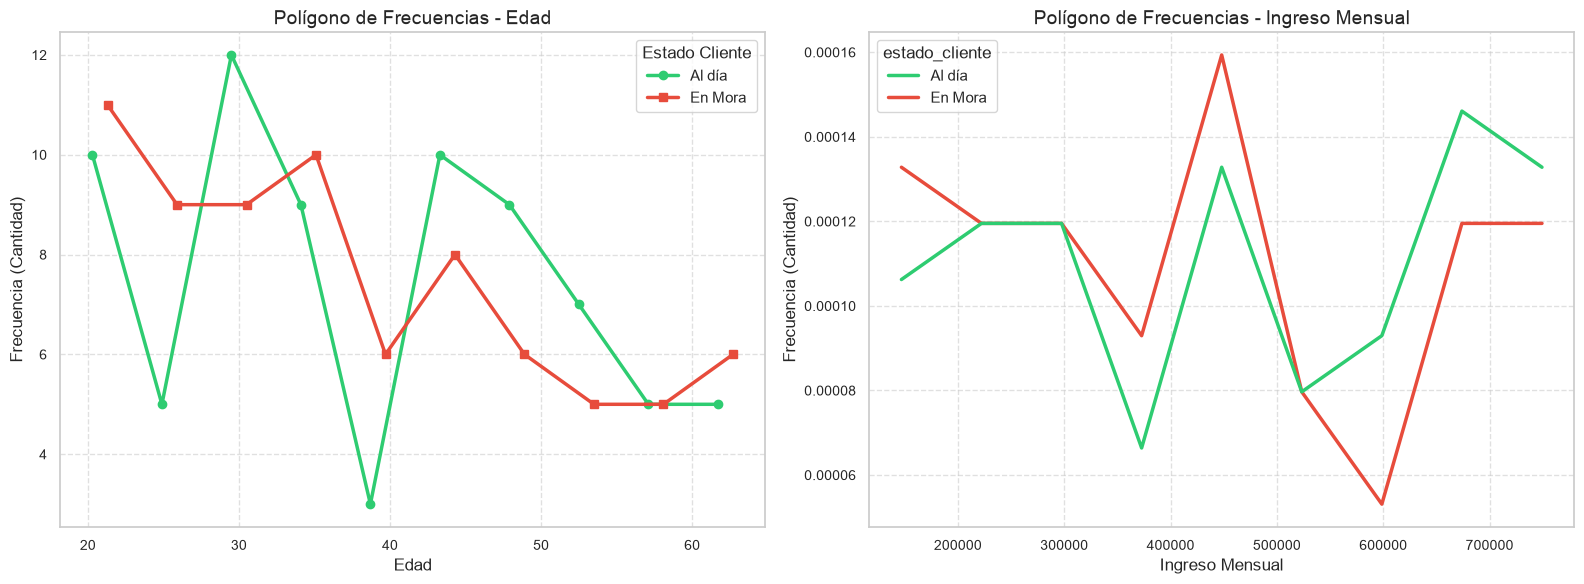

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Polígono de Frecuencia para Edad (Construcción Manual)
counts_ok, edges_ok = np.histogram(df[df['mora'] == 0]['edad'], bins=10)
counts_mora, edges_mora = np.histogram(df[df['mora'] == 1]['edad'], bins=10)

# Calcular centros de los intervalos (bins)
centers_ok = (edges_ok[:-1] + edges_ok[1:]) / 2
centers_mora = (edges_mora[:-1] + edges_mora[1:]) / 2

axes[0].plot(centers_ok, counts_ok, marker='o', label='Al día', color='#2ecc71', linewidth=2.5)
axes[0].plot(centers_mora, counts_mora, marker='s', label='En Mora', color='#e74c3c', linewidth=2.5)
axes[0].set_title('Polígono de Frecuencias - Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia (Cantidad)')
axes[0].legend(title="Estado Cliente")
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Polígono de Frecuencia para Ingreso Mensual (Usando Seaborn)
sns.histplot(
    data=df, 
    x='ingreso_mensual', 
    hue='estado_cliente', 
    element='poly', 
    fill=False, 
    stat='frequency', 
    common_norm=False, 
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'}, 
    linewidth=2.5, 
    ax=axes[1]
)
axes[1].set_title('Polígono de Frecuencias - Ingreso Mensual')
axes[1].set_xlabel('Ingreso Mensual')
axes[1].set_ylabel('Frecuencia (Cantidad)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Diagrama de Caja (Box Plot)

El **diagrama de caja (box plot)** nos permite evaluar la dispersión, la simetría, la mediana y la presencia de valores atípicos (outliers) en las variables continuas. 

Analizaremos:
1. **Ingreso Mensual:** Comparando los ingresos de clientes al día vs. en mora.
2. **Score Crediticio:** Comparando la distribución del score de riesgo de ambos grupos.

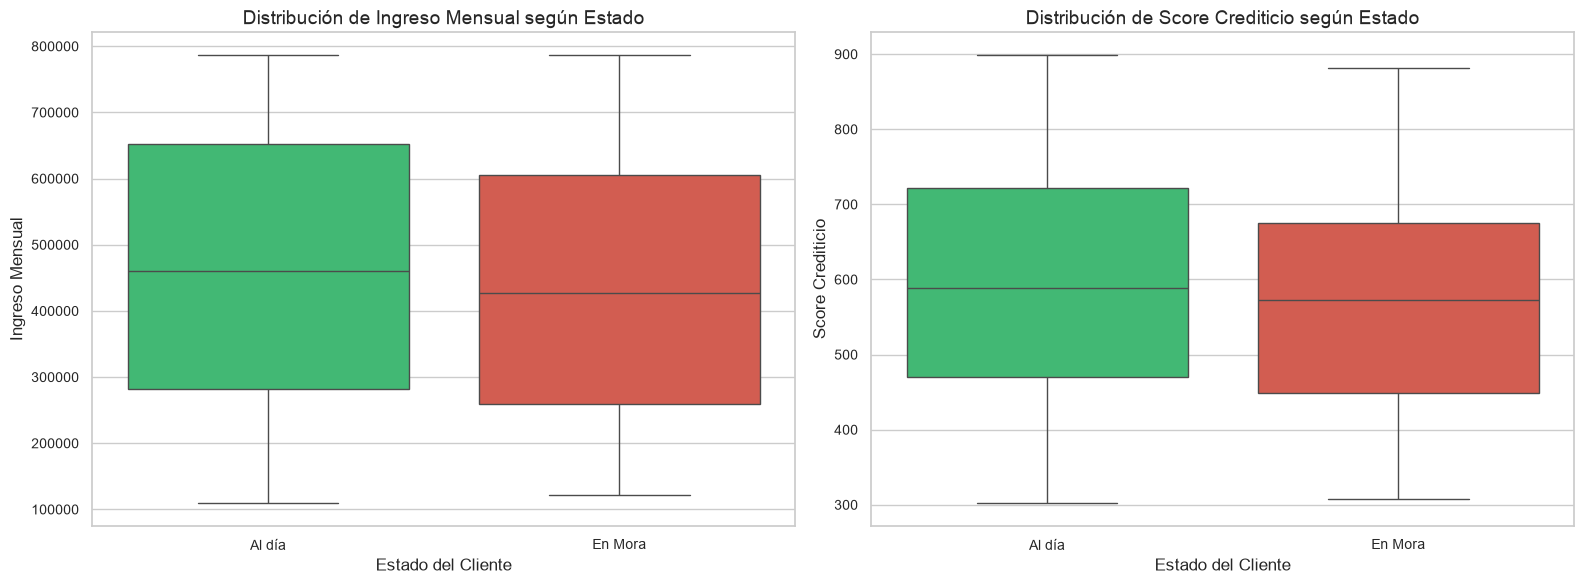

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot para Ingreso Mensual
sns.boxplot(
    data=df, 
    x='estado_cliente', 
    y='ingreso_mensual', 
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'}, 
    hue='estado_cliente', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Distribución de Ingreso Mensual según Estado')
axes[0].set_xlabel('Estado del Cliente')
axes[0].set_ylabel('Ingreso Mensual')

# Boxplot para Score Crediticio
sns.boxplot(
    data=df, 
    x='estado_cliente', 
    y='score_crediticio', 
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'}, 
    hue='estado_cliente', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Distribución de Score Crediticio según Estado')
axes[1].set_xlabel('Estado del Cliente')
axes[1].set_ylabel('Score Crediticio')

plt.tight_layout()
plt.show()

## 5. Diagrama de Dispersión (Scatter Plot)

El **diagrama de dispersión** sirve para explorar la interacción entre dos variables numéricas simultáneamente.

Graficamos la relación entre el **Ingreso Mensual** y el **Monto del Crédito**, coloreando por el **Estado del Cliente**, para examinar visualmente si existen patrones de mora asociados a montos elevados con ingresos bajos.

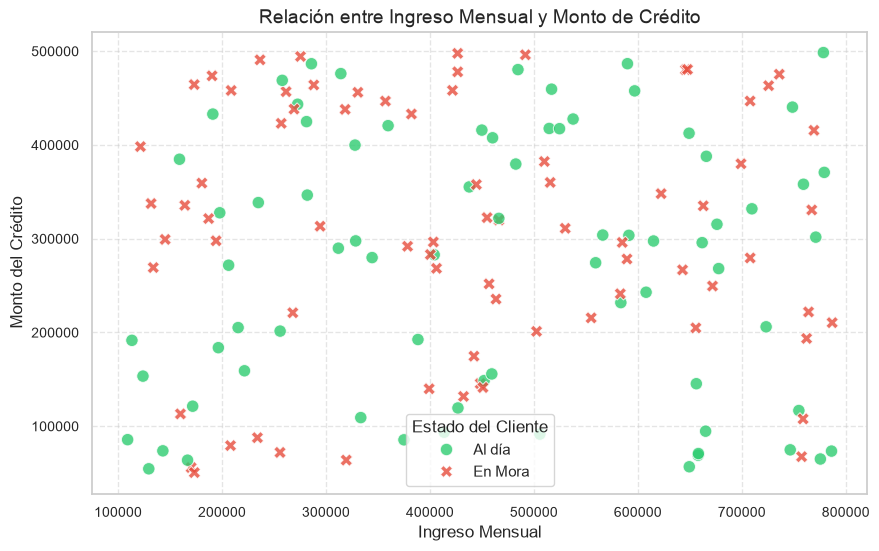

In [6]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='ingreso_mensual', 
    y='monto_credito', 
    hue='estado_cliente', 
    style='estado_cliente',
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'},
    alpha=0.8,
    s=80
)

plt.title('Relación entre Ingreso Mensual y Monto de Crédito')
plt.xlabel('Ingreso Mensual')
plt.ylabel('Monto del Crédito')
plt.legend(title='Estado del Cliente')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6. Matriz de Correlación de Variables Numéricas

Por último, calculamos el coeficiente de correlación lineal de Pearson entre las variables continuas para identificar la intensidad de las relaciones lineales directas o inversas.

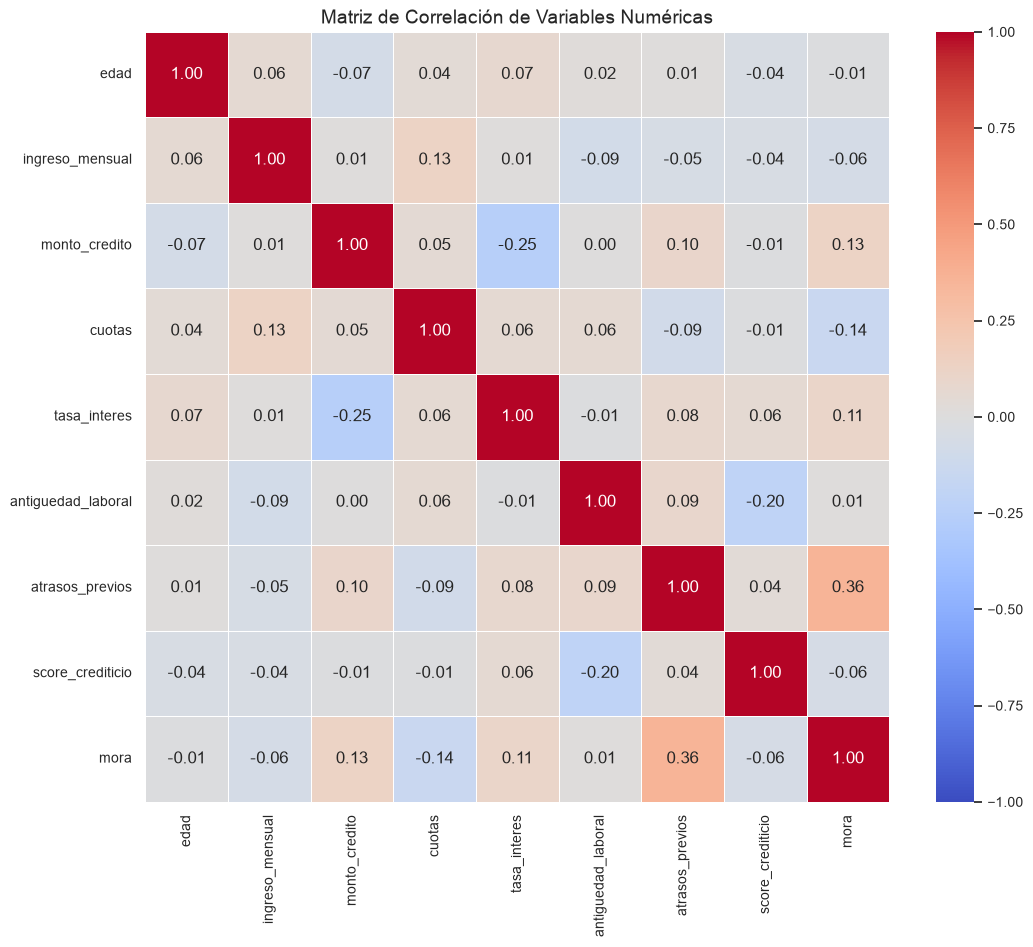

In [7]:
# Seleccionar variables numéricas excluyendo id_cliente
num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'id_cliente']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()